Explained Variance Ratio:
[0.75628013 0.19205327]


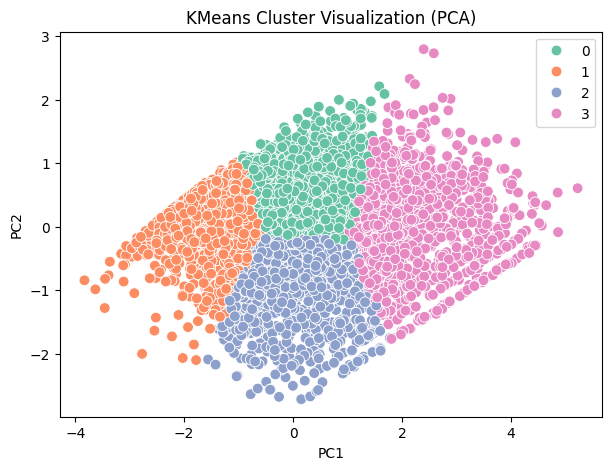

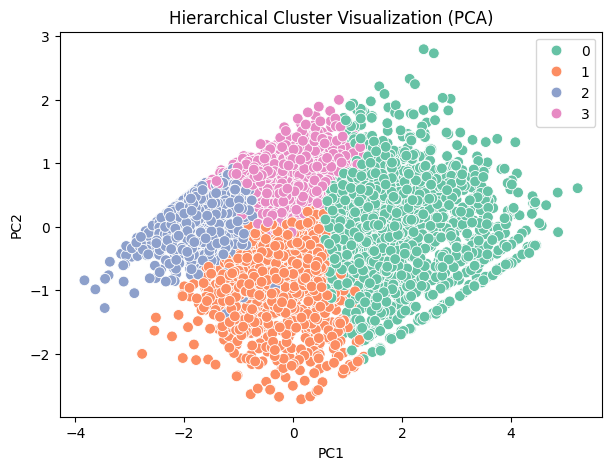

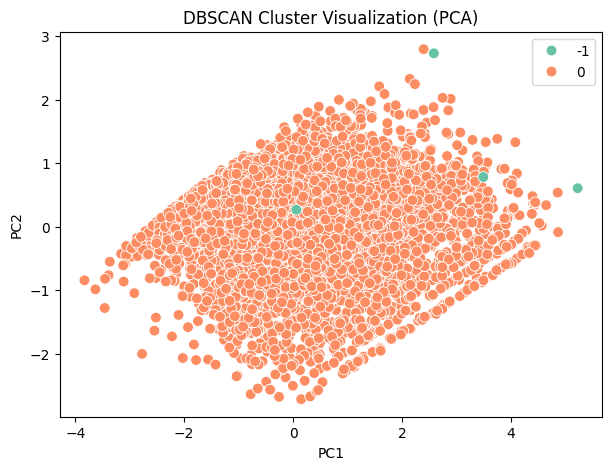

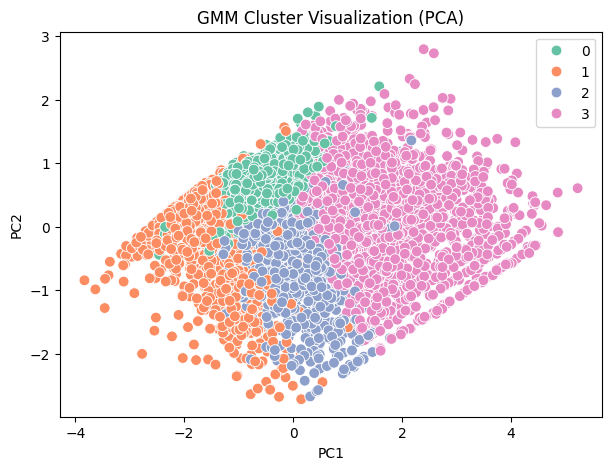

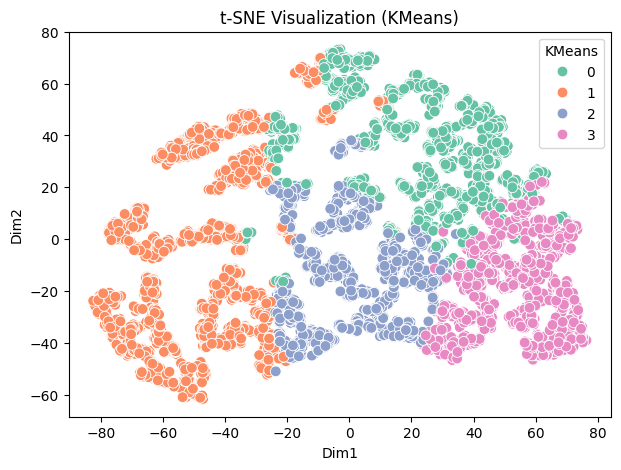

Cluster Visualization Completed Successfully.


In [1]:
# ==========================================
# CLUSTER VISUALIZATION USING PCA
# ==========================================

# -------------------------------
# 1. Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE

# -------------------------------
# 2. Create Result Folders
# -------------------------------

os.makedirs("../results/cluster_plots", exist_ok=True)
os.makedirs("../results/pca_outputs", exist_ok=True)

# -------------------------------
# 3. Load RFM Data
# -------------------------------

rfm = pd.read_csv("../data/processed/rfm_data.csv", index_col=0)

# Scale the data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# ==========================================
# 4. APPLY PCA (Reduce to 2 Components)
# ==========================================

pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(rfm_pca, columns=["PC1", "PC2"])

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# ==========================================
# 5. APPLY CLUSTERING (k = 4)
# ==========================================

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
pca_df["KMeans"] = kmeans.fit_predict(rfm_scaled)

# Hierarchical
hierarchical = AgglomerativeClustering(n_clusters=4)
pca_df["Hierarchical"] = hierarchical.fit_predict(rfm_scaled)

# DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
pca_df["DBSCAN"] = dbscan.fit_predict(rfm_scaled)

# GMM
gmm = GaussianMixture(n_components=4, random_state=42)
pca_df["GMM"] = gmm.fit_predict(rfm_scaled)

# ==========================================
# 6. VISUALIZE CLUSTERS
# ==========================================

def plot_clusters(model_name):

    plt.figure(figsize=(7,5))

    sns.scatterplot(
        x="PC1",
        y="PC2",
        hue=model_name,
        palette="Set2",
        data=pca_df,
        s=60
    )

    plt.title(f"{model_name} Cluster Visualization (PCA)")
    plt.legend()

    # Save plot
    plt.savefig(f"../results/cluster_plots/{model_name}_pca_clusters.png")

    plt.show()

# Plot for each model
plot_clusters("KMeans")
plot_clusters("Hierarchical")
plot_clusters("DBSCAN")
plot_clusters("GMM")

# ==========================================
# 7. t-SNE VISUALIZATION (Bonus)
# ==========================================

tsne = TSNE(n_components=2, random_state=42, perplexity=30)

rfm_tsne = tsne.fit_transform(rfm_scaled)

tsne_df = pd.DataFrame(rfm_tsne, columns=["Dim1", "Dim2"])
tsne_df["KMeans"] = pca_df["KMeans"]

plt.figure(figsize=(7,5))

sns.scatterplot(
    x="Dim1",
    y="Dim2",
    hue="KMeans",
    palette="Set2",
    data=tsne_df,
    s=60
)

plt.title("t-SNE Visualization (KMeans)")

plt.savefig("../results/cluster_plots/tsne_kmeans_clusters.png")

plt.show()

# ==========================================
# 8. Save PCA Output Data
# ==========================================

pca_df.to_csv("../results/pca_outputs/pca_cluster_visualization.csv")

print("Cluster Visualization Completed Successfully.")